In [94]:
print("Hello, HR Analytics!")

Hello, HR Analytics!


In [95]:
import pandas as pd

In [96]:
import pandas as pd

In [97]:
import pandas as pd

In [98]:
import pandas as pd

print(pd.__version__)

3.0.1


In [99]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [100]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [102]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [103]:
attrition_rate = (237 / 1470) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [104]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [105]:
df.groupby("Department")["Attrition"].value_counts()

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

In [106]:
pd.crosstab(df["Department"], df["Attrition"])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [107]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

department_attrition

Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Attrition, dtype: float64

## Business Insight 1: Department-wise Attrition

- Research & Development has the highest number of employees, so it also records the highest number of employees leaving.
- However, comparing raw counts is misleading because department sizes differ.
- After calculating attrition rates:
  - Sales: 20.63%
  - Human Resources: 19.05%
  - Research & Development: 13.84%
- Sales has the highest employee attrition rate and should be prioritized for retention initiatives.


In [108]:
pd.crosstab(df["OverTime"], df["Attrition"])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [109]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

overtime_attrition

OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

In [110]:
df["MonthlyIncome"].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

## Business Insight 2: Impact of Overtime on Attrition

### Observation
- Employees without overtime have an attrition rate of **10.44%**.
- Employees working overtime have an attrition rate of **30.53%**.

### Business Insight
Employees working overtime are nearly **3 times more likely** to leave the organization.

### Recommendation
The HR department should investigate overtime policies, workload distribution, and work-life balance initiatives to reduce employee turnover.

In [111]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


## Business Insight 3: Monthly Income and Employee Attrition

### Observation
- Employees who left the company earned significantly lower salaries than employees who stayed.
- Average Monthly Income:
  - Stayed: 6833
  - Left: 4787
- Median Monthly Income:
  - Stayed: 5204
  - Left: 3202

### Business Insight
Lower-paid employees are more likely to leave the organization, suggesting that compensation may be an important factor influencing attrition.

### Recommendation
HR should review compensation policies for lower-income employee groups and evaluate whether salary adjustments or additional benefits could improve employee retention.

<Figure size 800x500 with 0 Axes>

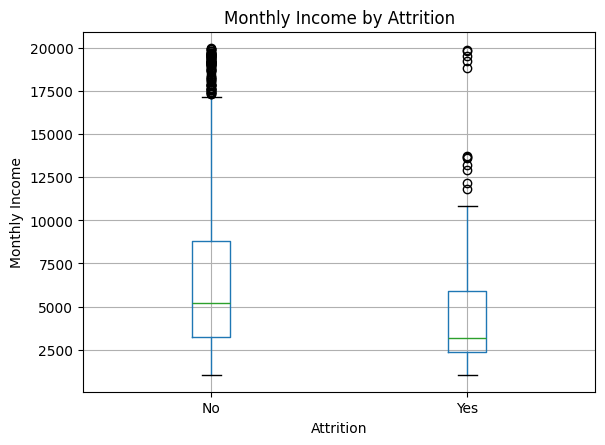

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

## Job Role Analysis

Now I want to see whether employee attrition differs across various job roles. This can help identify which roles are experiencing higher employee turnover.

### Business Question

Which job role has the highest employee attrition?

In [113]:
# Number of employees who stayed and left in each job role

pd.crosstab(df["JobRole"], df["Attrition"])

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [114]:
job_attrition = df.groupby("JobRole")["Attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

job_attrition = job_attrition.round(2)

job_attrition

JobRole
Healthcare Representative     6.87
Human Resources              23.08
Laboratory Technician        23.94
Manager                       4.90
Manufacturing Director        6.90
Research Director             2.50
Research Scientist           16.10
Sales Executive              17.48
Sales Representative         39.76
Name: Attrition, dtype: float64

### What I found

After analyzing the data, I found that **Sales Representatives** have the highest attrition rate (39.76%), followed by **Laboratory Technicians** (23.94%). On the other hand, **Research Directors** have the lowest attrition rate (2.50%).

### My Interpretation

Sales Representatives appear to leave the company more frequently than employees in other job roles. This may indicate challenges such as higher work pressure, demanding sales targets, or limited career growth. However, the dataset does not provide the exact reasons, so this should be treated as a hypothesis rather than a conclusion.

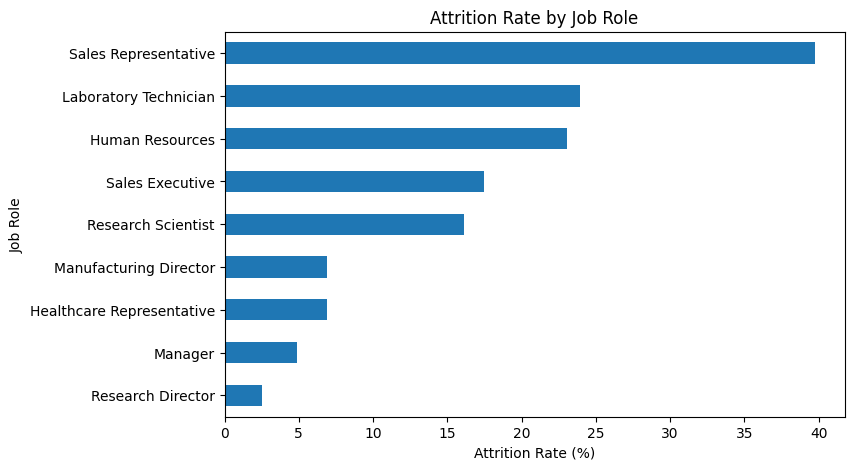

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

job_attrition.sort_values().plot(kind="barh")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

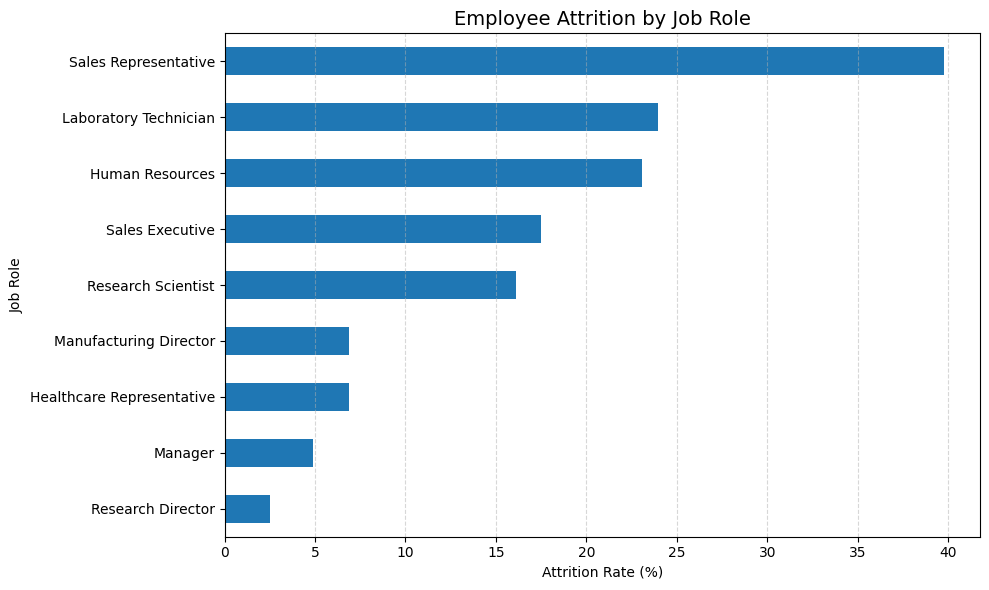

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

job_attrition.sort_values().plot(kind="barh")

plt.title("Employee Attrition by Job Role", fontsize=14)
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

## Recommendations

1. Review compensation policies for lower-income employee groups to determine whether salary competitiveness is contributing to employee attrition.

2. Conduct targeted employee feedback sessions and exit interviews with Sales Representatives, as this role shows the highest attrition rate.

3. Monitor employee overtime and implement workload management strategies to reduce excessive overtime and improve employee retention.

In [117]:
job_satisfaction_attrition = (
    df.groupby("JobSatisfaction")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

job_satisfaction_attrition

JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64

### What I Found

Employees with **Low Job Satisfaction** have the highest attrition rate (22.84%), while employees with **Very High Job Satisfaction** have the lowest attrition rate (11.33%).

### My Interpretation

The results suggest that employees with lower job satisfaction are more likely to leave the company. Improving employee engagement, recognition, and workplace satisfaction may help reduce attrition. However, this analysis shows an association and does not prove that job satisfaction is the direct cause of attrition.

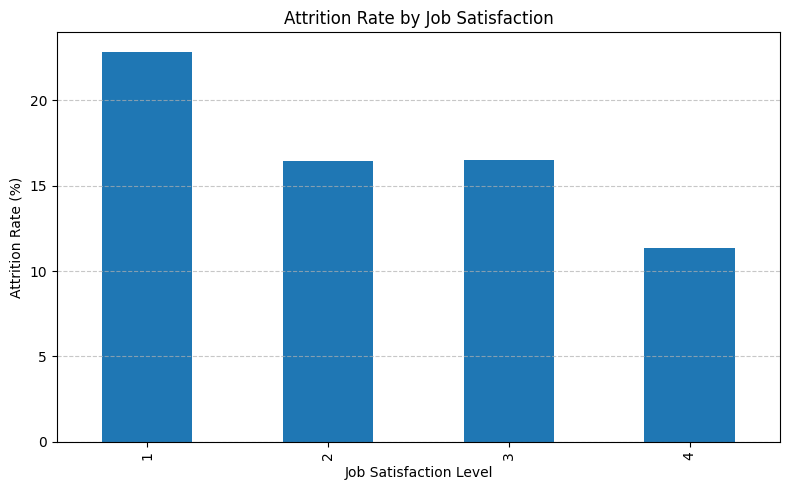

In [118]:
plt.figure(figsize=(8,5))

job_satisfaction_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

In [119]:
## Business Question 8

### Does work-life balance influence employee attrition?

### Hypothesis

I think employees with poor work-life balance may have a higher attrition rate because an unhealthy balance between work and personal life can reduce employee satisfaction and increase the likelihood of leaving the organization.

In [120]:
work_life_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

work_life_attrition

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64

In [121]:
work_life_attrition.index = [
    "Bad",
    "Good",
    "Better",
    "Best"
]

work_life_attrition

Bad       31.25
Good      16.86
Better    14.22
Best      17.65
Name: Attrition, dtype: float64

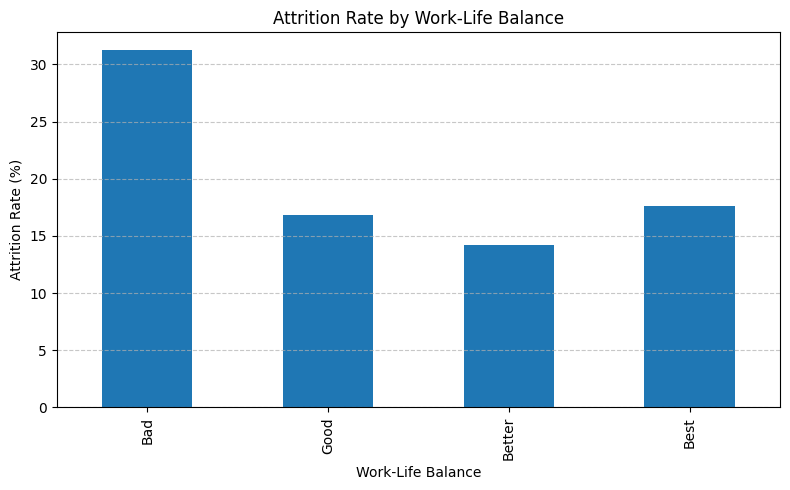

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

work_life_attrition.plot(kind="bar")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

### What I Found

Employees with poor work-life balance have the highest attrition rate, while employees with better work-life balance generally show lower attrition rates.

### My Interpretation

The analysis suggests that poor work-life balance may be associated with higher employee attrition. Organizations that support a healthier balance between work and personal life may improve employee retention.

### Recommendation

HR should identify employees reporting poor work-life balance and introduce initiatives such as flexible work arrangements, workload management, and employee wellness programs to improve retention.

### Business Impact

Improving employees' work-life balance may help reduce attrition, lower recruitment and training costs, and improve overall workforce productivity.

## Business Question 9

### Does business travel influence employee attrition?

### Hypothesis

I think employees who travel frequently may have a higher attrition rate because frequent business travel can increase work-related stress, reduce work-life balance, and affect overall job satisfaction.

In [123]:
business_travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

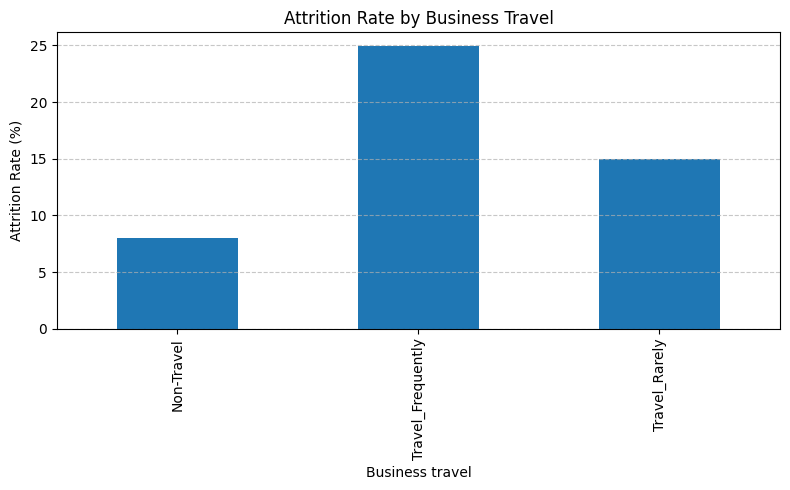

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

business_travel_attrition.plot(kind="bar")

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business travel")
plt.ylabel("Attrition Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

### What I Found

Employees who travel frequently have the highest attrition rate, while employees who do not travel have the lowest attrition rate. Employees who travel rarely fall between these two groups.

### My Interpretation

The analysis suggests that frequent business travel may be associated with higher employee attrition. Employees who travel more often may experience increased work-related stress, fatigue, or reduced work-life balance, which could contribute to a higher likelihood of leaving the organization.

### Recommendation

HR should review travel policies for employees who travel frequently. Where possible, the organization can reduce unnecessary travel, rotate travel responsibilities among employees, or provide additional support and flexibility to frequent travelers.

### Business Impact

Reducing excessive business travel may help improve employee retention, lower recruitment and training costs, and maintain a more stable and productive workforce.

In [125]:
business_travel_attrition.index = [
    "Non-Travel",
    "Travel Frequently",
    "Travel Rarely"
]

## Business Question 10

### Does Marital Status influence employee attrition?

### Hypothesis

I think single employees may have a higher attrition rate because they may be more willing to switch jobs or relocate compared to married employees.

In [126]:
marital_status_attrition = (
    df.groupby("MaritalStatus")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

In [127]:
marital_status_attrition

MaritalStatus
Divorced    10.09
Married     12.48
Single      25.53
Name: Attrition, dtype: float64

### What I Found
The analysis shows that single employees have the highest attrition rate (25.53%), followed by married employees (12.48%) and divorced employees (10.09%). This indicates that single employees are associated with a higher likelihood of leaving the organization.

### My Interpretation
One possible explanation is that single employees may be more willing to explore new career opportunities or relocate for better prospects. Married employees may prefer greater job stability due to family responsibilities. However, this analysis only shows an association and does not prove that marital status is the direct cause of attrition.

### Recommendation
The HR team should identify employees who may be at a higher risk of attrition and improve retention through career development opportunities, recognition programs, flexible work policies, and regular feedback sessions. Retention strategies should consider multiple factors rather than marital status alone.

### Business Impact
Reducing attrition among high-risk employee groups can lower recruitment and training costs, improve workforce stability, and help retain experienced employees, ultimately improving organizational productivity.

### Business Question 11
Does employee age influence attrition?

### Hypothesis
Employees in younger age groups may have higher attrition rates because they are more likely to explore new career opportunities, whereas older employees may prefer greater job stability.

In [128]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 60],
    labels=["18-25", "26-35", "36-45", "46-55", "56-60"]
)

In [129]:
age_group_attrition = (
    df.groupby("AgeGroup")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

In [130]:
age_group_attrition

AgeGroup
18-25    35.77
26-35    19.14
36-45     9.19
46-55    11.50
56-60    17.02
Name: Attrition, dtype: float64

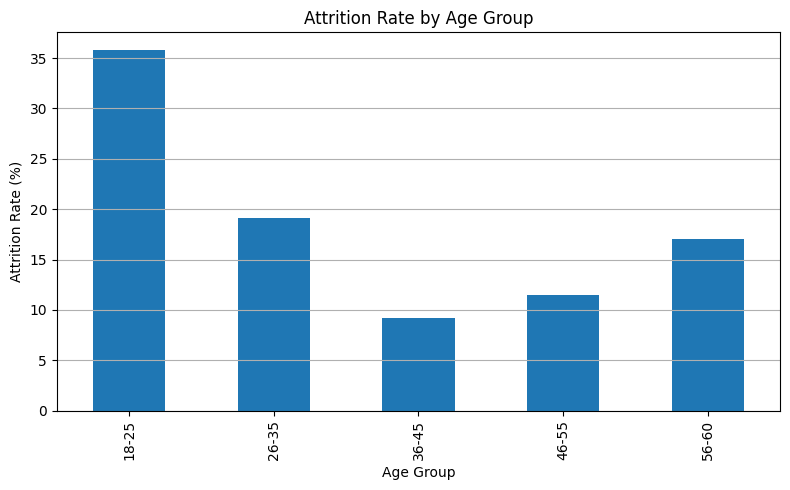

In [131]:
plt.figure(figsize=(8,5))

age_group_attrition.plot(kind="bar")

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

What I Found

Employees aged 18–25 have the highest attrition rate (35.77%), while employees aged 36–45 have the lowest attrition rate (9.19%). Overall, attrition generally decreases with age, although there is a slight increase in the 56–60 age group.

My Interpretation

Younger employees may be more likely to switch jobs in search of better career opportunities, higher salaries, or faster professional growth. Employees in the middle stages of their careers tend to show greater job stability. The increase in attrition among employees aged 56–60 may be influenced by factors such as retirement or other career decisions, but additional analysis would be needed to confirm the reason.

Recommendation

HR should strengthen retention initiatives for younger employees by providing clear career growth opportunities, mentoring programs, skill development, competitive compensation, and regular feedback.

Business Impact

Reducing attrition among younger employees can lower recruitment and training costs, improve workforce stability, and help retain talented employees for the long term.

## Business Question 12
Does Monthly Income influence employee attrition?

### Hypothesis

Employees with relatively lower monthly income are more likely to leave the company than employees with higher monthly income.

In [132]:
df["MonthlyIncome"].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [133]:
df["IncomeGroup"] = pd.cut(
    df["MonthlyIncome"],
    bins=[1009, 2911, 4919, 6000, 8379, 19999],
    labels=[
        "Low Income",
        "Lower Middle",
        "Middle",
        "Upper Middle",
        "High Income"
    ],
    include_lowest=True
)

In [134]:
income_group_attrition = (
    df.groupby("IncomeGroup")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

In [135]:
income_group_attrition

IncomeGroup
Low Income      29.27
Lower Middle    14.21
Middle          10.61
Upper Middle    10.64
High Income     10.33
Name: Attrition, dtype: float64

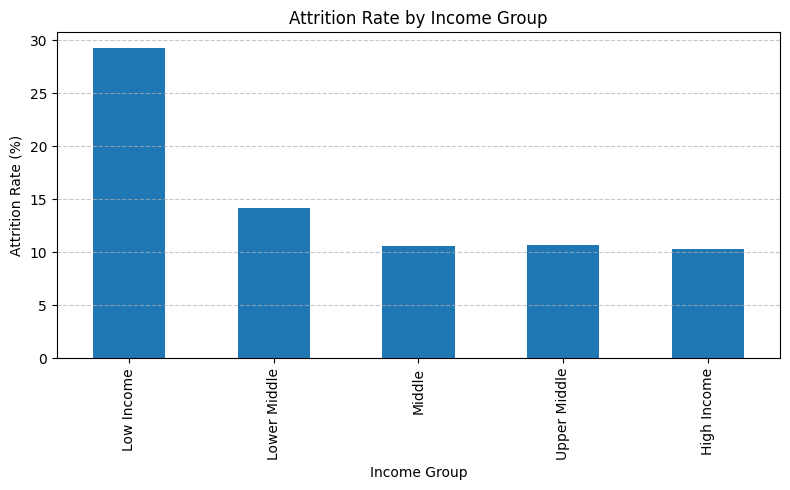

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

income_group_attrition.plot(kind="bar")

plt.title("Attrition Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Attrition Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

### What I Found
The analysis shows that employees in the **Low Income** group have the highest attrition rate (**29.27%**), whereas employees in the higher income groups have considerably lower attrition rates (around **10–14%**). This indicates that lower income is associated with a higher likelihood of employee attrition.

### My Interpretation
One possible explanation is that employees with lower salaries may seek better-paying opportunities in other organizations. However, this analysis only shows an association and does not prove that salary is the direct cause of attrition.

### Recommendation
The HR team should review the compensation structure for lower-income employees and ensure that salaries remain competitive in the market. Compensation reviews should be combined with career development opportunities and employee recognition programs to improve retention.

### Business Impact
Improving employee retention among lower-income groups can reduce recruitment, onboarding, and training costs while helping the organization retain experienced employees and maintain workforce stability.

### Business Question 13

### Does YearsAtCompany influence employee attrition?

### Hypothesis

Employees who have recently joined the organization may have a higher attrition rate than employees who have been with the company for a longer period. This may be because newer employees are still evaluating their job fit and may leave if they find better opportunities or if the role does not meet their expectations.

In [139]:
df["YearsAtCompany"].describe()

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

In [143]:
df["ExperienceGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 20, 40],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11-20 Years",
        "21-40 Years"
    ]
)

In [144]:
experience_group_attrition = (
    df.groupby("ExperienceGroup")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

In [146]:
experience_group_attrition

ExperienceGroup
0-2 Years      29.82
3-5 Years      13.82
6-10 Years     12.28
11-20 Years     6.67
21-40 Years    12.12
Name: Attrition, dtype: float64

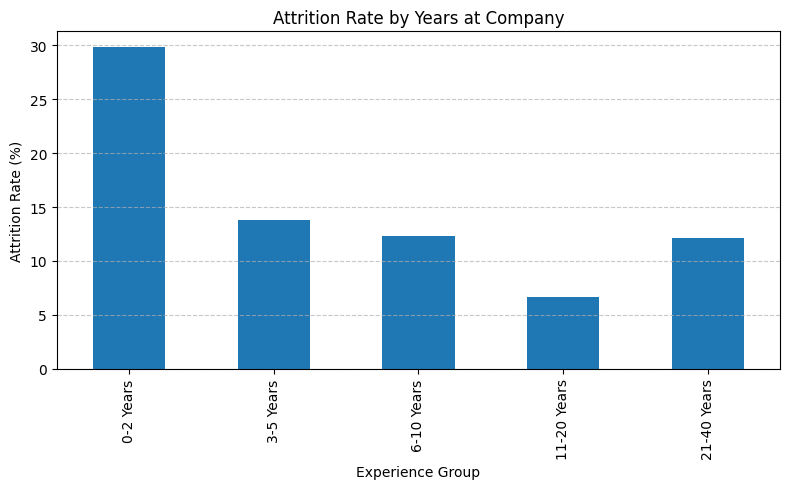

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

experience_group_attrition.plot(kind="bar")

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Experience Group")
plt.ylabel("Attrition Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

### What I Found
The analysis shows that employees with **0–2 years** of experience have the highest attrition rate (approximately **30%**). Attrition gradually decreases as employees spend more years in the organization. Employees with **11–20 years** of experience have the lowest attrition rate (around **7%**). There is a slight increase in attrition among employees with **21–40 years** of experience.

### My Interpretation
One possible explanation is that newly hired employees are still adapting to the organization and may leave if their expectations regarding the job, salary, or work environment are not met. Employees who stay with the company for several years generally demonstrate greater job stability and organizational commitment. The slight increase in attrition among employees with more than 20 years of experience may be associated with factors such as retirement or career transitions. However, this analysis shows an association and does not establish the exact cause of attrition.

### Recommendation
The HR team should strengthen onboarding programs, mentoring initiatives, and career development opportunities for employees during their first two years in the organization. Regular feedback sessions and employee engagement activities can also help improve early retention.

### Business Impact
Reducing early employee attrition can lower recruitment, onboarding, and training costs while improving workforce stability, retaining valuable talent, and increasing long-term organizational productivity.

# Executive Summary

This project analyzes the IBM HR Analytics Employee Attrition dataset to identify the major factors associated with employee attrition. Using Python, Pandas, and Matplotlib, exploratory data analysis (EDA) was performed to examine employee demographics, work-related factors, and organizational characteristics.

The analysis identified several important factors associated with higher attrition, including overtime, lower monthly income, poor work-life balance, younger age, fewer years at the company, frequent business travel, lower job satisfaction, and specific job roles. Based on these findings, business recommendations were proposed to help improve employee retention and support HR decision-making.

This project demonstrates the complete exploratory data analysis process, from data cleaning and visualization to business insight generation and strategic recommendations.

# Key Business Insights

The exploratory data analysis revealed several important insights regarding employee attrition:

- Employees working overtime have significantly higher attrition rates than employees who do not work overtime.
- Employees with poor work-life balance are more likely to leave the organization.
- Lower-income employees experience the highest attrition rate compared to higher-income employees.
- Employees aged 18–25 years have the highest attrition rate.
- Employees with 0–2 years at the company are more likely to leave than experienced employees.
- Employees who travel frequently for business have relatively higher attrition.
- Single employees show higher attrition compared to married employees.
- Employees with lower job satisfaction are more likely to leave the organization.
- Certain job roles, particularly Sales Representatives and Laboratory Technicians, experience comparatively higher attrition.
- The Sales department records the highest attrition among all departments.

# Final Business Recommendations

Based on the exploratory data analysis, the following recommendations are proposed to help reduce employee attrition and improve workforce stability:

1. **Reduce excessive overtime** by balancing employee workloads and encouraging a healthier work-life balance.

2. **Review the compensation structure** for lower-income employees to ensure salaries remain competitive with industry standards.

3. **Strengthen onboarding and mentoring programs** for newly hired employees, particularly during their first two years in the organization.

4. **Develop targeted retention strategies** for departments and job roles with consistently higher attrition rates, such as Sales and Sales Representatives.

5. **Create clear career growth opportunities** through learning programs, promotions, and regular performance feedback to improve employee engagement.

6. **Regularly monitor employee satisfaction** using surveys and feedback sessions so that concerns can be identified and addressed before employees decide to leave.

7. **Review business travel policies** and minimize unnecessary travel wherever possible to reduce employee stress and improve work-life balance.

8. **Implement personalized retention programs** for younger employees and employees identified as being at higher risk of attrition through periodic HR reviews and one-on-one discussions.

# Conclusion

This project successfully analyzed the IBM HR Analytics Employee Attrition dataset to identify factors associated with employee attrition. Through exploratory data analysis, multiple employee-related and organizational factors were examined to understand their relationship with attrition.

The findings indicate that overtime, work-life balance, salary, age, years at the company, business travel, job satisfaction, and job role are associated with employee attrition. These insights can help HR departments develop targeted retention strategies, improve employee satisfaction, and reduce recruitment and training costs.

Although this analysis identifies meaningful patterns within the data, it does not establish cause-and-effect relationships. Future analytical techniques can be applied to build predictive models and provide deeper insights into employee attrition.

# Future Scope

This project can be extended further through the following improvements:

- Build an interactive Power BI dashboard for HR decision-making.
- Perform SQL-based analysis directly on the HR database.
- Conduct Excel-based analysis using Pivot Tables and Pivot Charts.
- Develop machine learning models to predict employee attrition.
- Compare multiple machine learning algorithms to identify the most accurate predictive model.
- Deploy the project as an interactive HR analytics dashboard for business users.

# Acknowledgements

This project was completed using the following tools and resources:

- IBM HR Analytics Employee Attrition Dataset
- Python
- Pandas
- Matplotlib
